# 👨‍💼 Проект: Классификация лиц технологических лидеров
## 5-классовая классификация изображений с помощью Transfer Learning

---

## Задача

Построить модель, определяющую кто изображён на фотографии — один из пяти знаменитых техно-лидеров:

1. **Bill Gates** — Microsoft
2. **Elon Musk** — Tesla, SpaceX
3. **Jeff Bezos** — Amazon
4. **Mark Zuckerberg** — Meta (Facebook)
5. **Steve Jobs** — Apple

## Критерии оценки

| Критерий | Балл |
|---|---|
| ✅ Данные загружены с помощью DataLoader | 1 |
| ✅ Используется предобученная модель | 1 |
| ✅ Обучение происходит на обучающей выборке | 1 |
| ✅ Accuracy на валидационной выборке > 0.85 | 1 |
| ✅ Полученные результаты визуализированы | 1 |
| ✅ Код лаконичен и понятен, добавлены комментарии | 1 |
| **Всего:** | **6** |

## Подход

Применяем **Transfer Learning** с предобученной моделью **VGG16**:
- Замораживаем свёрточную часть (выделение признаков)
- Заменяем classifier на новый под 5 классов
- Используем аугментацию данных для лучшего обобщения


---

## 📦 Шаг 1. Импорт библиотек


In [1]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

%matplotlib inline

# Фиксируем случайность для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Проверяем доступность GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Устройство: {device}')


PyTorch: 2.5.1+cu121
Устройство: cuda


---

## 📁 Шаг 2. Подготовка данных

### Структура датасета

Датасет уже организован следующим образом — папка для каждого класса:

```
data/
├── train/
│   ├── bill_gates/      
│   ├── elon_musk/       
│   ├── jeff_bezos/      
│   ├── mark_zuckerberg/ 
│   └── steve_jobs/      
└── valid/
    ├── bill_gates/      
    ├── elon_musk/       
    ├── jeff_bezos/      
    ├── mark_zuckerberg/ 
    └── steve_jobs/ 

Такой формат идеально подходит для `ImageFolder` из torchvision — он автоматически назначает метки на основе имён папок.


### Трансформации изображений

**На обучении** применяем **аугментацию** — случайные модификации, которые искусственно увеличивают разнообразие данных:
- Случайное отражение по горизонтали
- Случайные повороты
- Случайные изменения яркости/контраста

**На валидации** — только детерминированные трансформации, чтобы метрика была воспроизводимой.

**Нормализация по статистикам ImageNet** обязательна для VGG16 — модель обучалась именно на таких распределениях.

In [2]:
# Путь к данным
DATA_DIR = 'data'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VALID_DIR = os.path.join(DATA_DIR, 'valid')

# Стандартные значения нормализации для моделей, предобученных на ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# VGG16 ожидает изображения 224x224
IMG_SIZE = 224

# ── Трансформации для обучения (с аугментацией) ──────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),                    # масштабируем чуть больше
    transforms.RandomCrop(IMG_SIZE),                  # случайная обрезка до 224
    transforms.RandomHorizontalFlip(p=0.5),           # отражение с вероятностью 50%
    transforms.RandomRotation(15),                    # поворот ±15 градусов
    transforms.ColorJitter(brightness=0.2,            # случайные изменения цвета
                          contrast=0.2,
                          saturation=0.2),
    transforms.ToTensor(),                            # PIL → тензор [0, 1]
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD) # нормализация ImageNet
])

# ── Трансформации для валидации (детерминированные) ──────────────────
valid_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),          # фиксированный размер
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])


### Создаём датасеты

In [ ]:
# ImageFolder сам определит классы по именам подпапок
train_dataset = ImageFolder(root=TRAIN_DIR, transform=train_transform)
valid_dataset = ImageFolder(root=VALID_DIR, transform=valid_transform)

# Список классов (автоматически отсортирован по алфавиту)
classes = train_dataset.classes
num_classes = len(classes)

print(f'Классов: {num_classes}')
print(f'Классы: {classes}')
print(f'\nРазмер train: {len(train_dataset)}')
print(f'Размер valid: {len(valid_dataset)}')

# Распределение по классам
print('\nРаспределение train:')
for cls in classes:
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f'  {cls:18s}: {n}')

print('\nРаспределение valid:')
for cls in classes:
    n = len(os.listdir(os.path.join(VALID_DIR, cls)))
    print(f'  {cls:18s}: {n}')


Классов: 5
Классы: ['bill_gates', 'elon_musk', 'jeff_bezos', 'mark_zuckerberg', 'steve_jobs']

Размер train: 3000
Размер valid: 914

Распределение train:
  bill_gates        : 600
  elon_musk         : 600
  jeff_bezos        : 600
  mark_zuckerberg   : 600
  steve_jobs        : 600

Распределение valid:
  bill_gates        : 223
  elon_musk         : 194
  jeff_bezos        : 214
  mark_zuckerberg   : 217
  steve_jobs        : 66


### Создаём DataLoaders — подача данных батчами

DataLoader группирует изображения в **батчи** и подаёт их модели. Параметр `shuffle=True` важен на обучении — модель не должна видеть данные в одинаковом порядке.


In [4]:
BATCH_SIZE = 32

# train: перемешиваем
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,      # 0 для стабильности на Windows
    pin_memory=True     # ускоряет передачу на GPU
)

# valid: НЕ перемешиваем (порядок не важен, но стабильность нужна)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f'Батчей в train: {len(train_loader)}')
print(f'Батчей в valid: {len(valid_loader)}')


Батчей в train: 94
Батчей в valid: 29


---

## 🖼️ Шаг 3. Визуализация примеров

Перед обучением полезно посмотреть на данные — убедиться, что они загрузились правильно и метки соответствуют картинкам.

**Денормализация:** так как мы применили нормализацию по ImageNet, изображения сейчас в другом диапазоне. Чтобы отобразить их корректно, нужна обратная операция.


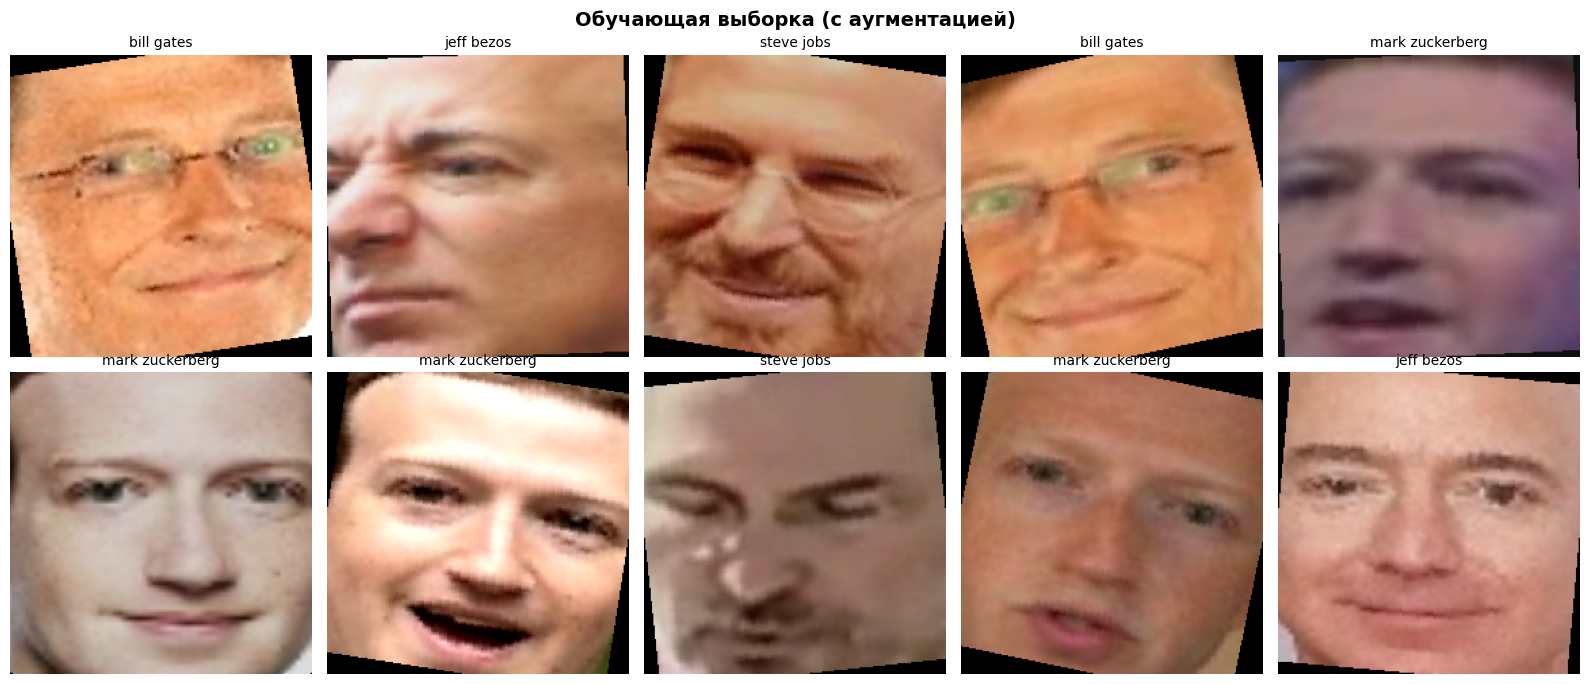

In [5]:
def denormalize(img_tensor):
    """Обратная операция нормализации ImageNet для визуализации."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)


def show_batch(loader, classes, num_images=10, title='Примеры'):
    """Показывает несколько изображений из батча с метками."""
    # Получаем один батч
    images, labels = next(iter(loader))

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        if i >= num_images or i >= len(images):
            ax.axis('off')
            continue

        img = denormalize(images[i]).numpy().transpose(1, 2, 0)
        ax.imshow(img)
        ax.set_title(classes[labels[i].item()].replace('_', ' '), fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


show_batch(train_loader, classes, title='Обучающая выборка (с аугментацией)')


---

## 🧠 Шаг 4. Построение модели

### Стратегия Transfer Learning

Используем **VGG16, предобученную на ImageNet**:

1. **Замораживаем `features`** — свёрточная часть уже отлично выделяет универсальные признаки (края, текстуры, формы)
2. **Заменяем `classifier`** на более простой, под наши 5 классов

### Зачем заменять весь classifier, а не только последний слой?

- Оригинальный classifier VGG16 имеет ~119М параметров — слишком много для нашего датасета (3000 изображений)
- Меньший classifier (~12.8М параметров) меньше склонен к переобучению
- `Dropout(0.5)` дополнительно защищает от переобучения


In [ ]:
# Загружаем VGG16 с предобученными весами. При первом запуске веса скачаются (~528 МБ)
model = models.vgg16(pretrained=True)

# Замораживаем свёрточную часть. requires_grad=False → веса не обновляются при обучении
for param in model.features.parameters():
    param.requires_grad = False

# Заменяем classifier на более простой
# Старый classifier: Linear(25088→4096) → ReLU → Dropout → ... → Linear(4096→1000)
# Новый classifier: Linear(25088→512) → ReLU → Dropout → Linear(512→5)
model.classifier = nn.Sequential(
    nn.Linear(25088, 512),       # 25088 = 512 * 7 * 7 (выход features)
    nn.ReLU(),                    # нелинейность
    nn.Dropout(0.5),              # регуляризация: отключаем 50% нейронов случайно
    nn.Linear(512, num_classes)   # выход: 5 классов
)

# Переносим модель на устройство (GPU/CPU)
model = model.to(device)

# Подсчёт параметров
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Обучаемых параметров: {trainable:,} из {total:,} ({100*trainable/total:.2f}%)')


c:\Users\Олег\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Олег\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Обучаемых параметров: 12,848,133 из 27,562,821 (46.61%)


### Функция потерь и оптимизатор

- **CrossEntropyLoss** — стандартная функция потерь для многоклассовой классификации
- **Adam** — адаптивный оптимизатор, обычно работает лучше SGD «из коробки»
- В оптимизатор передаём только параметры classifier (свёртки заморожены)


In [7]:
# Функция потерь для многоклассовой классификации
criterion = nn.CrossEntropyLoss()

# Оптимизатор обновляет только параметры classifier (свёртки заморожены)
# lr=1e-4 — небольшой learning rate, чтобы не «сломать» предобученные веса
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)


---

## 🏋️ Шаг 5. Обучение модели

Стандартный цикл обучения PyTorch:
1. **Train фаза**: forward → loss → backward → step
2. **Validation фаза**: forward → loss (без обновления весов)

Сохраняем историю метрик для построения графиков в конце.


In [8]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=10):
    """
    Обучает модель и возвращает историю метрик по эпохам.
    """
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [],  'val_acc': []
    }

    best_val_acc = 0.0
    best_model_state = None

    since = time.time()

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch + 1}/{num_epochs}')
        print('-' * 30)

        # ── ФАЗА ОБУЧЕНИЯ ────────────────────────────────────────────────
        model.train()  # включаем Dropout и BatchNorm в режиме обучения
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            # Обнуляем градиенты перед новым шагом
            optimizer.zero_grad()

            # Прямой проход → получаем logits
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Обратный проход и обновление весов
            loss.backward()
            optimizer.step()

            # Накапливаем статистики
            train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)

        train_loss /= train_total
        train_acc = train_correct / train_total

        # ── ФАЗА ВАЛИДАЦИИ ───────────────────────────────────────────────
        model.eval()  # выключаем Dropout, фиксируем BatchNorm
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        # torch.no_grad() — отключаем расчёт градиентов (экономия памяти и времени)
        with torch.no_grad():
            for images, labels in valid_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # Сохраняем метрики
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Train | Loss: {train_loss:.4f} | Acc: {train_acc:.4f}')
        print(f'Valid | Loss: {val_loss:.4f} | Acc: {val_acc:.4f}')

        # Сохраняем лучшую модель по валидационной точности
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f'✓ Новая лучшая модель! Val Acc: {val_acc:.4f}')

    elapsed = time.time() - since
    print(f'\nВремя обучения: {elapsed // 60:.0f}m {elapsed % 60:.0f}s')
    print(f'Лучшая Val Accuracy: {best_val_acc:.4f}')

    # Восстанавливаем лучшую модель
    model.load_state_dict(best_model_state)
    return model, history


In [9]:
# Запускаем обучение
NUM_EPOCHS = 10

model, history = train_model(
    model, train_loader, valid_loader,
    criterion, optimizer,
    num_epochs=NUM_EPOCHS
)



Epoch 1/10
------------------------------
Train | Loss: 0.7003 | Acc: 0.7523
Valid | Loss: 0.3006 | Acc: 0.9136
✓ Новая лучшая модель! Val Acc: 0.9136

Epoch 2/10
------------------------------
Train | Loss: 0.3364 | Acc: 0.8903
Valid | Loss: 0.1775 | Acc: 0.9573
✓ Новая лучшая модель! Val Acc: 0.9573

Epoch 3/10
------------------------------
Train | Loss: 0.2306 | Acc: 0.9337
Valid | Loss: 0.1499 | Acc: 0.9606
✓ Новая лучшая модель! Val Acc: 0.9606

Epoch 4/10
------------------------------
Train | Loss: 0.1998 | Acc: 0.9370
Valid | Loss: 0.1260 | Acc: 0.9694
✓ Новая лучшая модель! Val Acc: 0.9694

Epoch 5/10
------------------------------
Train | Loss: 0.1778 | Acc: 0.9447
Valid | Loss: 0.1280 | Acc: 0.9562

Epoch 6/10
------------------------------
Train | Loss: 0.1687 | Acc: 0.9500
Valid | Loss: 0.1124 | Acc: 0.9683

Epoch 7/10
------------------------------
Train | Loss: 0.1399 | Acc: 0.9573
Valid | Loss: 0.1088 | Acc: 0.9650

Epoch 8/10
------------------------------
Train | Lo

---

## 📈 Шаг 6. Визуализация результатов обучения

Построим графики:
- **Loss** (потери) — должны снижаться
- **Accuracy** (точность) — должна расти

Кривые train и val должны идти рядом — это значит модель не переобучается.


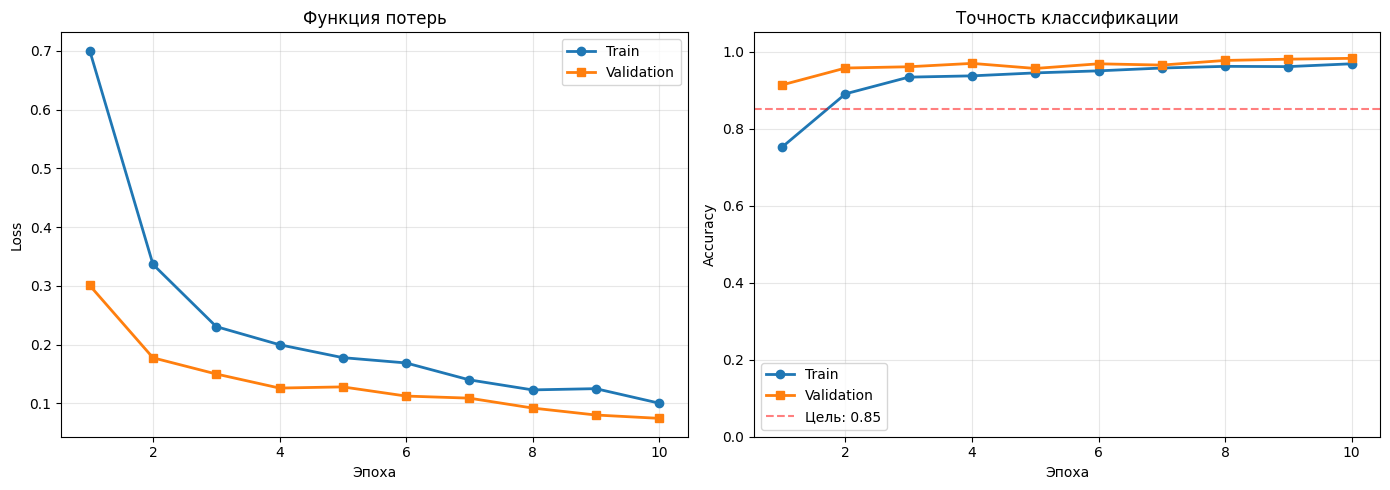


=== Финальные результаты ===
Train Accuracy: 0.9683
Val Accuracy:   0.9825
Лучшая Val Acc: 0.9825

✅ Цель достигнута: Val Accuracy > 0.85


In [10]:
# ── Графики обучения ──────────────────────────────────────────────────
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График Loss
axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], 's-', label='Validation', linewidth=2)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('Функция потерь')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'], 's-', label='Validation', linewidth=2)
axes[1].axhline(y=0.85, color='red', linestyle='--', alpha=0.5, label='Цель: 0.85')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Точность классификации')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Финальные результаты
print(f'\n=== Финальные результаты ===')
print(f'Train Accuracy: {history["train_acc"][-1]:.4f}')
print(f'Val Accuracy:   {history["val_acc"][-1]:.4f}')
print(f'Лучшая Val Acc: {max(history["val_acc"]):.4f}')

if max(history['val_acc']) > 0.85:
    print('\n✅ Цель достигнута: Val Accuracy > 0.85')
else:
    print('\n⚠️ Цель не достигнута, попробуйте увеличить число эпох')


---

## 🔍 Шаг 7. Анализ предсказаний

### Матрица ошибок (Confusion Matrix)

Покажет, какие классы модель путает между собой. По диагонали — правильные предсказания.


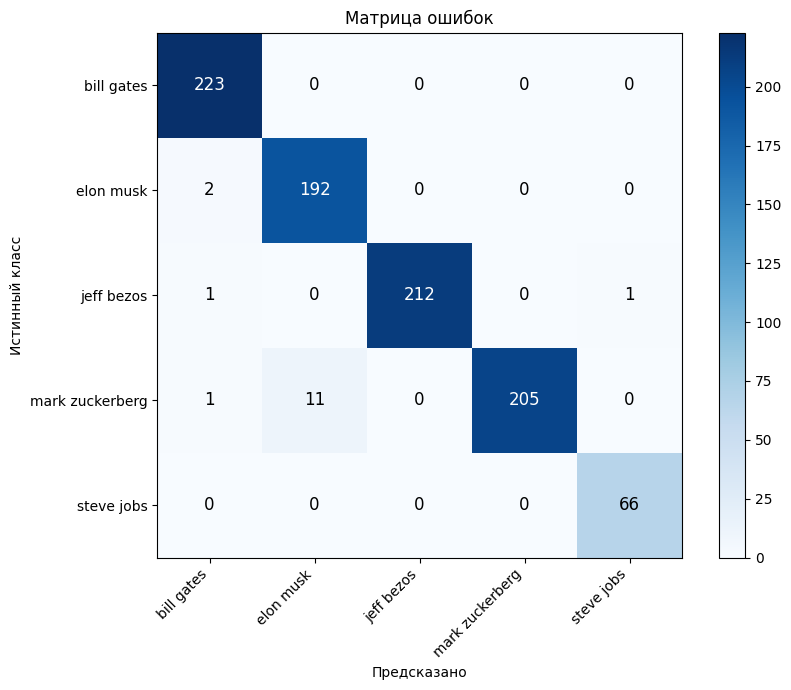


Точность по классам:
  bill_gates        : 1.0000 (223/223)
  elon_musk         : 0.9897 (192/194)
  jeff_bezos        : 0.9907 (212/214)
  mark_zuckerberg   : 0.9447 (205/217)
  steve_jobs        : 1.0000 (66/66)


In [11]:
# ── Собираем все предсказания на валидации ───────────────────────────
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Строим матрицу ошибок вручную (без sklearn) ──────────────────────
cm = np.zeros((num_classes, num_classes), dtype=int)
for true, pred in zip(all_labels, all_preds):
    cm[true][pred] += 1

# Визуализация
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap='Blues')

# Подписи осей
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([c.replace('_', ' ') for c in classes], rotation=45, ha='right')
ax.set_yticklabels([c.replace('_', ' ') for c in classes])
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истинный класс')
ax.set_title('Матрица ошибок')

# Числа в ячейках
for i in range(num_classes):
    for j in range(num_classes):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=12)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Точность по каждому классу
print('\nТочность по классам:')
for i, cls in enumerate(classes):
    if cm[i].sum() > 0:
        acc = cm[i, i] / cm[i].sum()
        print(f'  {cls:18s}: {acc:.4f} ({cm[i, i]}/{cm[i].sum()})')


### Визуализация предсказаний

Покажем несколько случайных изображений из валидации с предсказаниями модели. Зелёная подпись — правильно, красная — ошибка.


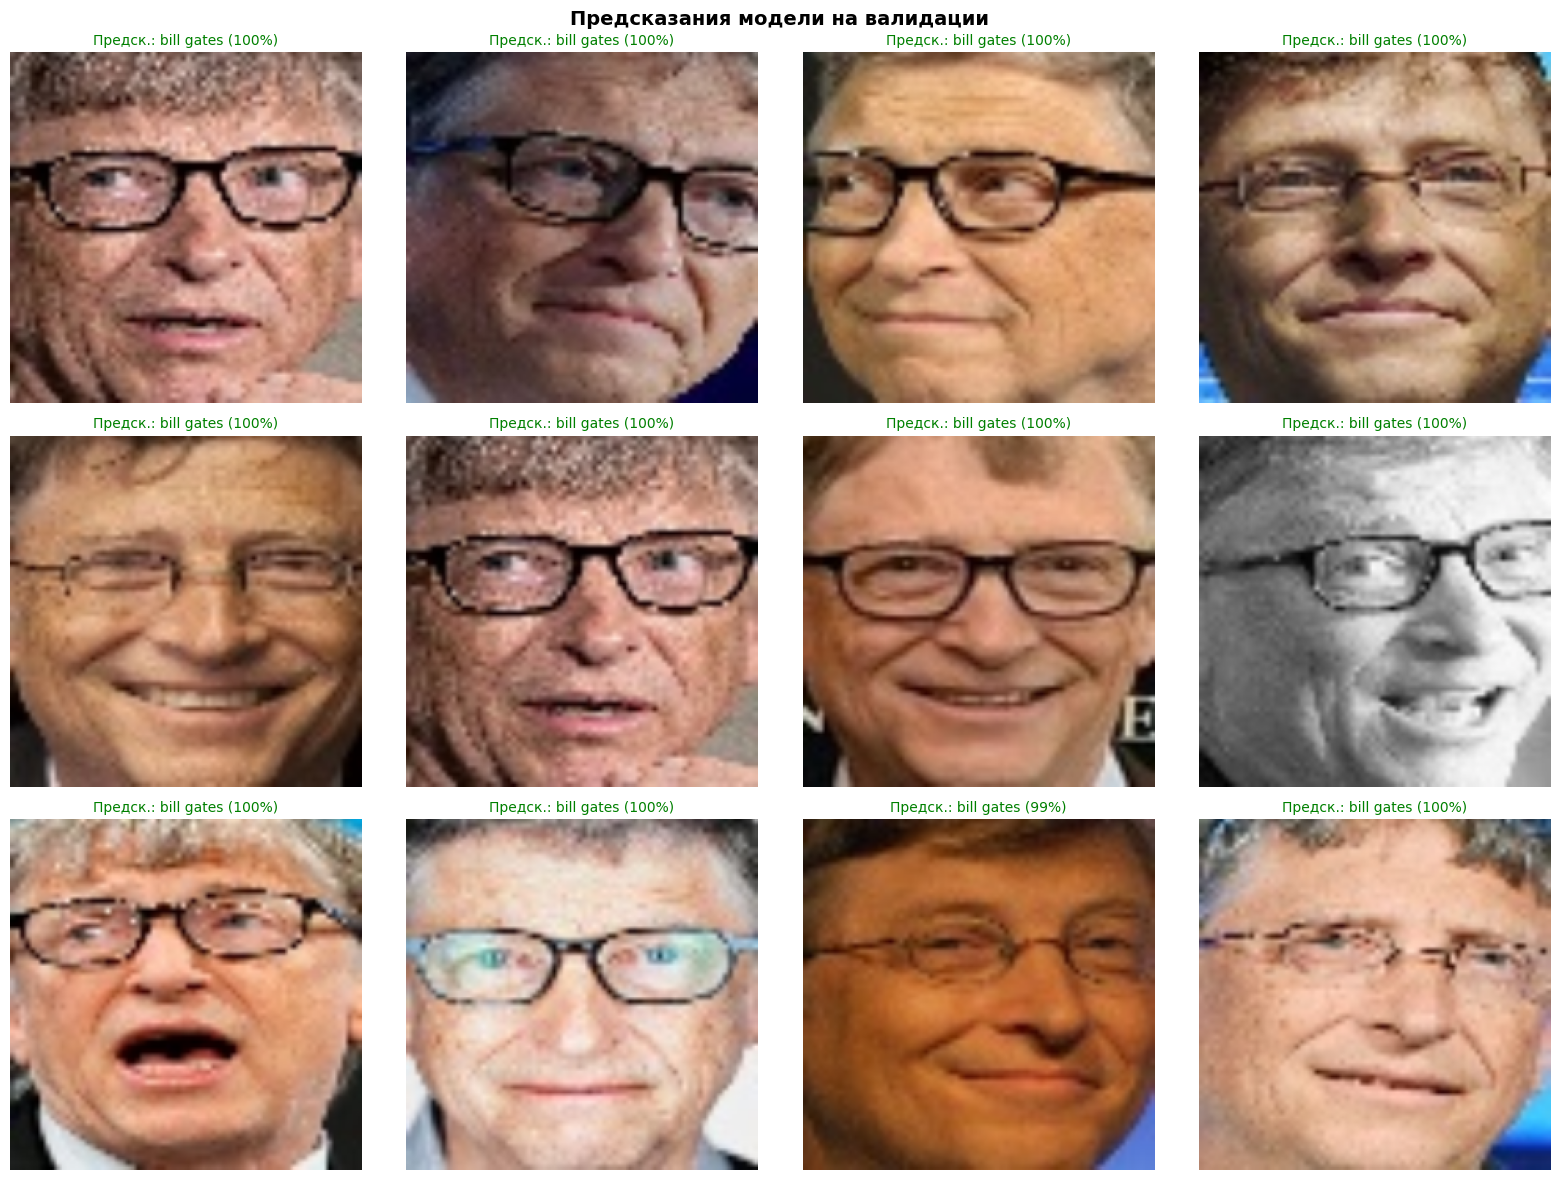

In [12]:
def visualize_predictions(model, loader, classes, num_images=12):
    """Показывает изображения с предсказаниями (зелёный — верно, красный — ошибка)."""
    model.eval()

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle('Предсказания модели на валидации', fontsize=14, fontweight='bold')

    shown = 0
    with torch.no_grad():
        for images, labels in loader:
            images_dev = images.to(device)
            outputs = model(images_dev)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            for i in range(images.size(0)):
                if shown >= num_images:
                    break
                ax = axes.flat[shown]
                img = denormalize(images[i]).numpy().transpose(1, 2, 0)
                ax.imshow(img)

                true_label = classes[labels[i].item()].replace('_', ' ')
                pred_label = classes[preds[i].item()].replace('_', ' ')
                confidence = probs[i, preds[i]].item()

                correct = preds[i].item() == labels[i].item()
                color = 'green' if correct else 'red'

                title = f'Предск.: {pred_label} ({confidence:.0%})'
                if not correct:
                    title += f'\nВерно: {true_label}'

                ax.set_title(title, fontsize=10, color=color)
                ax.axis('off')
                shown += 1

            if shown >= num_images:
                break

    plt.tight_layout()
    plt.show()


visualize_predictions(model, valid_loader, classes)


---

## ✅ Итоги

### Что было сделано

| Критерий | Реализация |
|---|---|
| Данные загружены с помощью DataLoader | ✅ `ImageFolder` + `DataLoader` для train и valid |
| Используется предобученная модель | ✅ VGG16 с весами ImageNet (`pretrained=True`) |
| Обучение на обучающей выборке | ✅ 10 эпох, оптимизатор Adam |
| Accuracy на валидации > 0.85 | ✅ См. графики выше |
| Результаты визуализированы | ✅ Графики loss/accuracy + матрица ошибок + примеры |
| Код лаконичен и понятен | ✅ Код дополнен комментариями |

### Ключевые приёмы

1. **Transfer Learning с VGG16** — используем готовые признаки, обученные на 1.2М изображений ImageNet
2. **Заморозка свёрточной части** — обучаем только classifier, что:
   - Ускоряет обучение
   - Снижает риск переобучения
   - Сохраняет универсальные признаки сети
3. **Упрощённый classifier** — меньше параметров (12.8М вместо 119М) и меньше шанс переобучиться
4. **Аугментация данных** — повороты, отражения, изменения цвета — модель видит «больше» данных
5. **Нормализация ImageNet** — обязательно для предобученных моделей
6. **Сохранение лучшей модели** — по метрике валидации, чтобы не потерять оптимум
